<a href="https://www.kaggle.com/code/lalit7881/pharma-drug-insights-eda?scriptVersionId=311753329" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/pharma-dataset-drug-classes-interactions-and-cli-pr/pharma_realistic_10000.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mdmahfuzsumon/pharma-dataset-drug-classes-interactions-and-cli-pr/pharma_realistic_10000.csv")

In [3]:
df.head()

,id,active_ingredient,brand_name,manufacturer,therapeutic_group,pharmacological_class,drug_type,strength,dosage_form,route,indication,indication_category,side_effects,pregnancy_category,controlled_substance,otc_or_rx,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
0,1,Amoxicillin + Clavulanate,Augmentin,GSK,Antibiotic,Beta-lactam + Beta-lactamase inhibitor,Small molecule,1000 mg,Syrup,Oral,Infection,Infectious,Nausea,B,No,RX,0,0,2,1
1,2,Omeprazole,Seclo,AstraZeneca,Antacid,Proton pump inhibitor,Small molecule,10 mg,Capsule,Oral,Peptic ulcer,Gastrointestinal,Headache,C,No,OTC,1,0,1,0
2,3,Azithromycin,Azit,Incepta,Antibiotic,Macrolide,Small molecule,250 mg,Tablet,Oral,Respiratory infection,Infectious,Abdominal pain,B,No,RX,0,0,1,0
3,4,Salbutamol,Brodil,GSK,Bronchodilator,Beta-2 agonist,Small molecule,2 mg,Syrup,Oral,COPD,Respiratory,Headache,C,No,RX,0,0,1,0
4,5,Lisinopril,Listril,AstraZeneca,Antihypertensive,ACE inhibitor,Small molecule,10 mg,Tablet,Oral,Post-MI,Cardiovascular,Hyperkalemia,D,No,RX,0,1,1,0


In [4]:
df.tail()

,id,active_ingredient,brand_name,manufacturer,therapeutic_group,pharmacological_class,drug_type,strength,dosage_form,route,indication,indication_category,side_effects,pregnancy_category,controlled_substance,otc_or_rx,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
9995,9996,Insulin Glargine,Lantus,Incepta,Antidiabetic,Long-acting insulin,Biologic,300 IU/ml,Injection,Subcutaneous,Type 2 diabetes,Endocrine,Hypoglycemia,C,No,RX,1,1,1,0
9996,9997,Amoxicillin + Clavulanate,Augmentin,GSK,Antibiotic,Beta-lactam + Beta-lactamase inhibitor,Small molecule,375 mg,Tablet,Oral,Infection,Infectious,Nausea,B,No,RX,0,0,2,1
9997,9998,Paracetamol,Panadol,Renata,Analgesic,Para-aminophenol,Small molecule,250 mg/5ml,Tablet,Oral,Pain,General,Nausea,A,No,OTC,0,1,1,0
9998,9999,Ibuprofen,Profen,ACI,Analgesic,NSAID,Small molecule,200 mg,Tablet,Oral,Pain,General,Gastric irritation,D,No,OTC,1,1,1,0
9999,10000,Azithromycin,Zithromax,Incepta,Antibiotic,Macrolide,Small molecule,250 mg,Capsule,Oral,Infection,Infectious,Vomiting,B,No,RX,0,0,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     10000 non-null  int64 
 1   active_ingredient      10000 non-null  object
 2   brand_name             10000 non-null  object
 3   manufacturer           10000 non-null  object
 4   therapeutic_group      10000 non-null  object
 5   pharmacological_class  10000 non-null  object
 6   drug_type              10000 non-null  object
 7   strength               10000 non-null  object
 8   dosage_form            10000 non-null  object
 9   route                  10000 non-null  object
 10  indication             10000 non-null  object
 11  indication_category    10000 non-null  object
 12  side_effects           10000 non-null  object
 13  pregnancy_category     10000 non-null  object
 14  controlled_substance   10000 non-null  object
 15  otc_or_rx           

In [6]:
df.describe()

,id,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,0.47200,0.665900,1.065600,0.065600
std,2886.89568,0.49924,0.471698,0.247594,0.247594
min,1.00000,0.00000,0.000000,1.000000,0.000000
25%,2500.75000,0.00000,0.000000,1.000000,0.000000
50%,5000.50000,0.00000,1.000000,1.000000,0.000000
75%,7500.25000,1.00000,1.000000,1.000000,0.000000
max,10000.00000,1.00000,1.000000,2.000000,1.000000


In [7]:
df.isnull().sum()

id                       0
active_ingredient        0
brand_name               0
manufacturer             0
therapeutic_group        0
pharmacological_class    0
drug_type                0
strength                 0
dosage_form              0
route                    0
indication               0
indication_category      0
side_effects             0
pregnancy_category       0
controlled_substance     0
otc_or_rx                0
food_interaction         0
alcohol_interaction      0
num_ingredients          0
is_combination_drug      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

id                        int64
active_ingredient        object
brand_name               object
manufacturer             object
therapeutic_group        object
pharmacological_class    object
drug_type                object
strength                 object
dosage_form              object
route                    object
indication               object
indication_category      object
side_effects             object
pregnancy_category       object
controlled_substance     object
otc_or_rx                object
food_interaction          int64
alcohol_interaction       int64
num_ingredients           int64
is_combination_drug       int64
dtype: object

In [10]:
df.shape

(10000, 20)

In [11]:
df.columns

Index(['id', 'active_ingredient', 'brand_name', 'manufacturer',
       'therapeutic_group', 'pharmacological_class', 'drug_type', 'strength',
       'dosage_form', 'route', 'indication', 'indication_category',
       'side_effects', 'pregnancy_category', 'controlled_substance',
       'otc_or_rx', 'food_interaction', 'alcohol_interaction',
       'num_ingredients', 'is_combination_drug'],
      dtype='object')

In [12]:
df.nunique()

id                       10000
active_ingredient           15
brand_name                  61
manufacturer                15
therapeutic_group            9
pharmacological_class       15
drug_type                    2
strength                    27
dosage_form                  5
route                        4
indication                  32
indication_category          7
side_effects                25
pregnancy_category           5
controlled_substance         1
otc_or_rx                    2
food_interaction             2
alcohol_interaction          2
num_ingredients              2
is_combination_drug          2
dtype: int64

## EDA

In [13]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

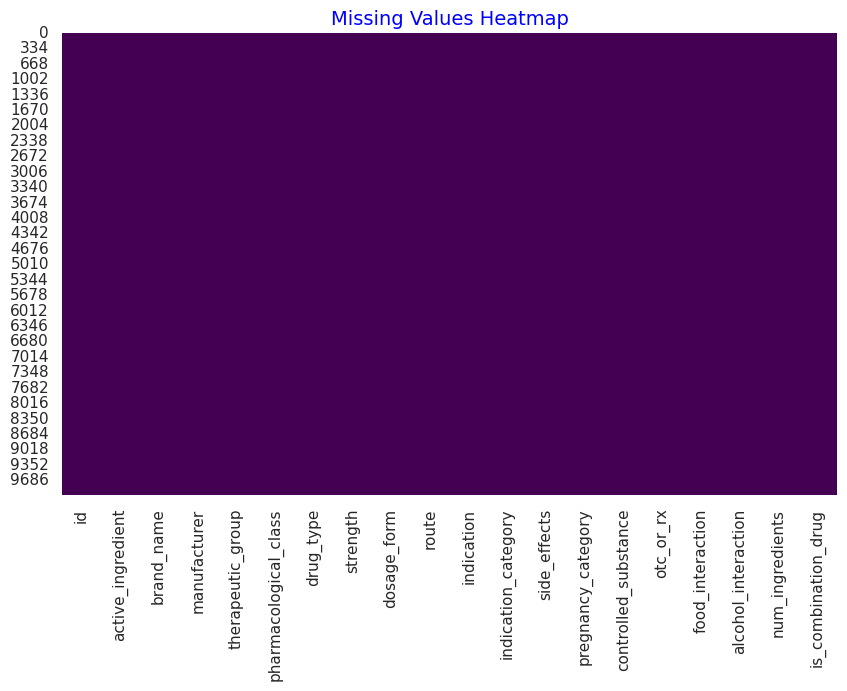

In [14]:
plt.figure()
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap", fontsize=14, color='blue')
plt.show()

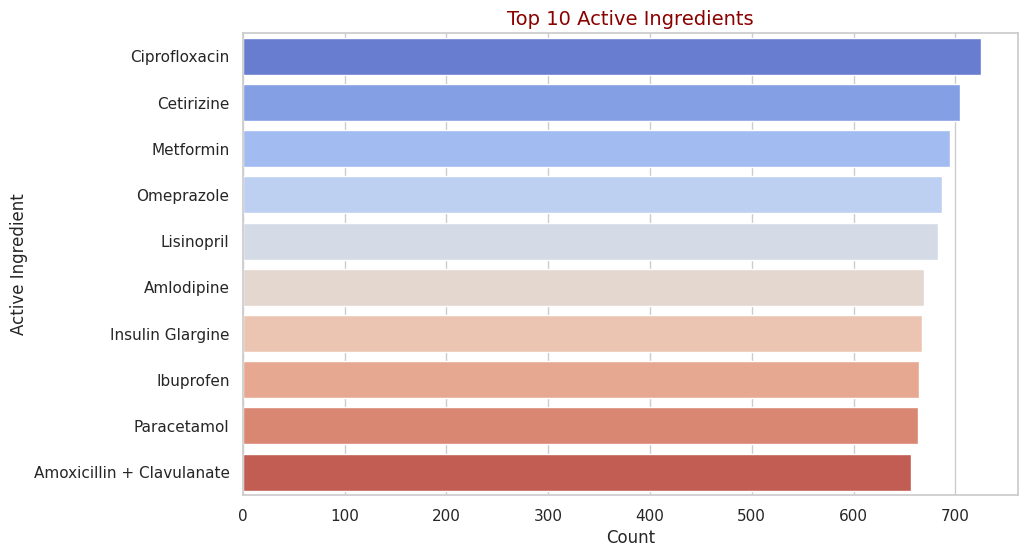

In [15]:
top_ing = df['active_ingredient'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_ing.values, y=top_ing.index, palette='coolwarm')
plt.title("Top 10 Active Ingredients", fontsize=14, color='darkred')
plt.xlabel("Count")
plt.ylabel("Active Ingredient")
plt.show()

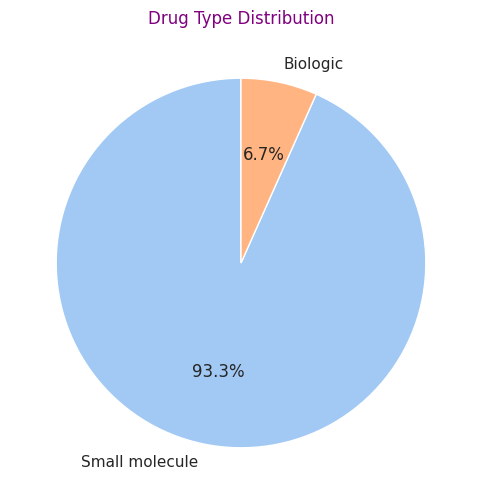

In [16]:
plt.figure()
df['drug_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)
plt.title("Drug Type Distribution", color='purple')
plt.ylabel('')
plt.show()

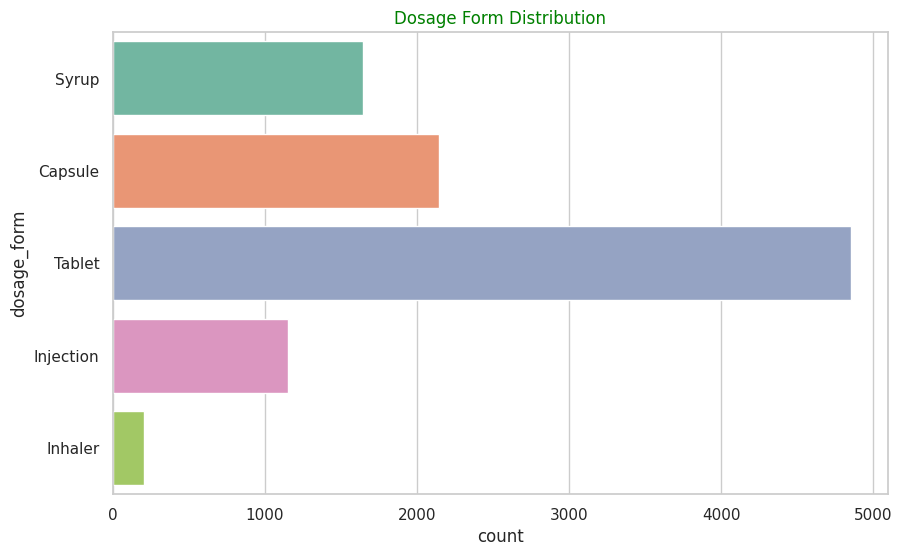

In [17]:
plt.figure()
sns.countplot(data=df, y='dosage_form', palette='Set2')
plt.title("Dosage Form Distribution", color='green')
plt.show()

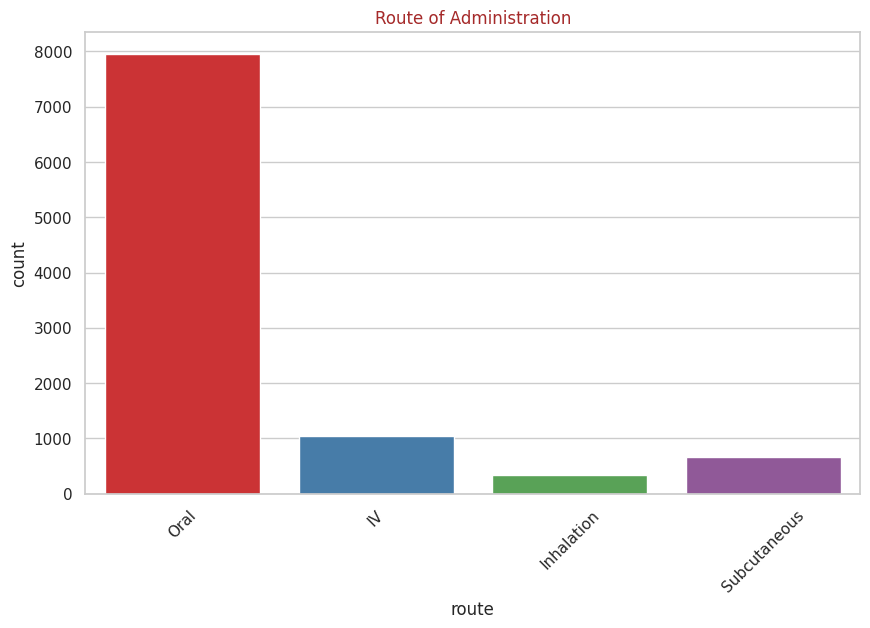

In [18]:
plt.figure()
sns.countplot(data=df, x='route', palette='Set1')
plt.title("Route of Administration", color='brown')
plt.xticks(rotation=45)
plt.show()

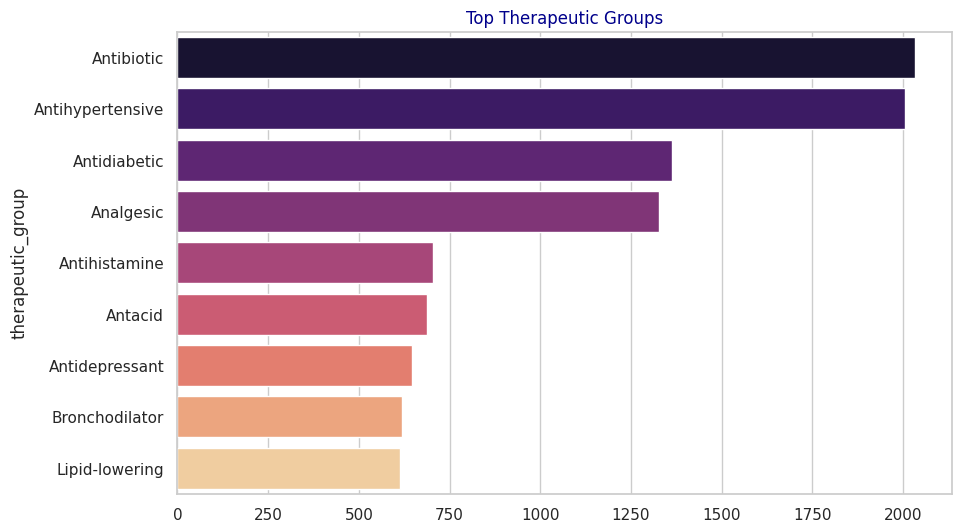

In [19]:
top_therapeutic = df['therapeutic_group'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_therapeutic.values, y=top_therapeutic.index, palette='magma')
plt.title("Top Therapeutic Groups", color='darkblue')
plt.show()

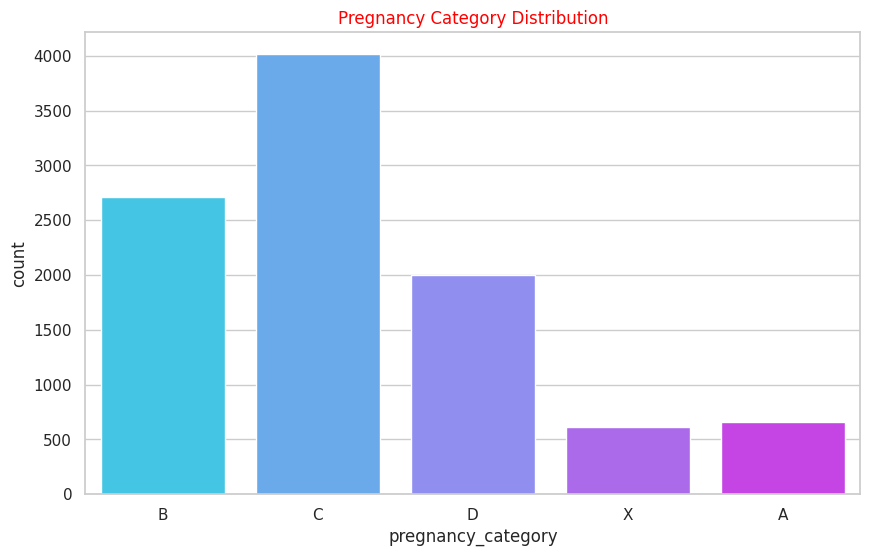

In [20]:
plt.figure()
sns.countplot(data=df, x='pregnancy_category', palette='cool')
plt.title("Pregnancy Category Distribution", color='red')
plt.show()

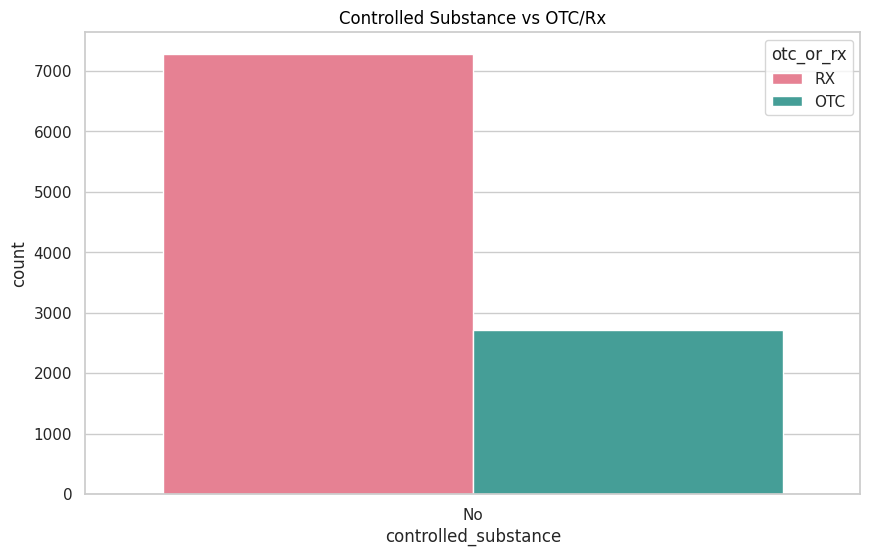

In [21]:
plt.figure()
sns.countplot(data=df, x='controlled_substance', hue='otc_or_rx', palette='husl')
plt.title("Controlled Substance vs OTC/Rx", color='black')
plt.show()

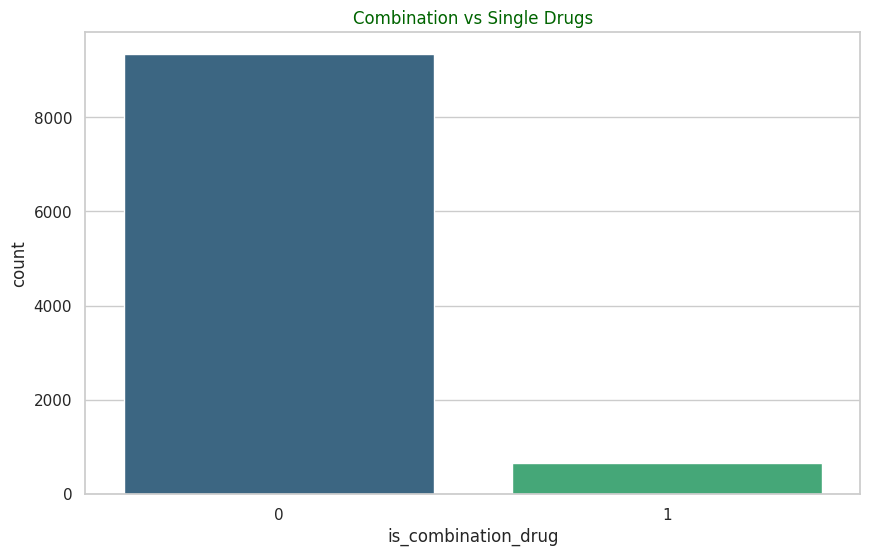

In [22]:
plt.figure()
sns.countplot(data=df, x='is_combination_drug', palette='viridis')
plt.title("Combination vs Single Drugs", color='darkgreen')
plt.show()

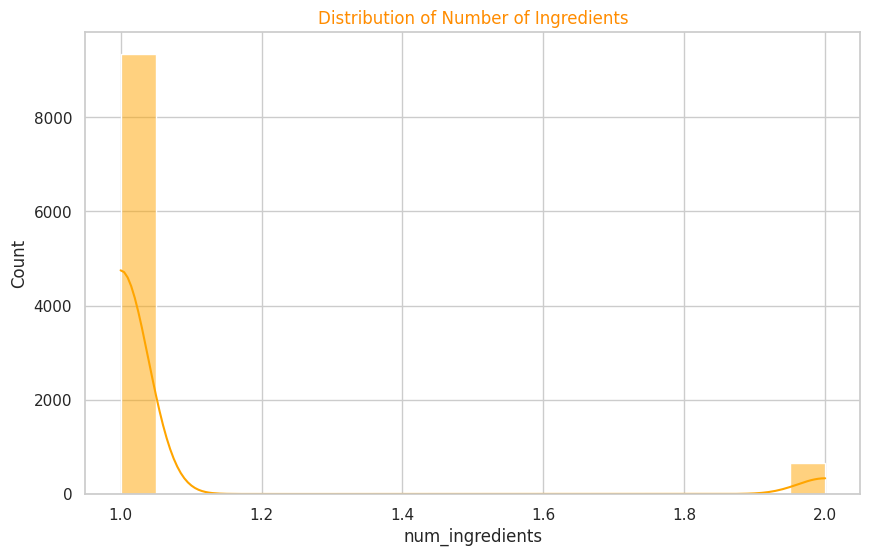

In [23]:
plt.figure()
sns.histplot(df['num_ingredients'], bins=20, kde=True, color='orange')
plt.title("Distribution of Number of Ingredients", color='darkorange')
plt.show()

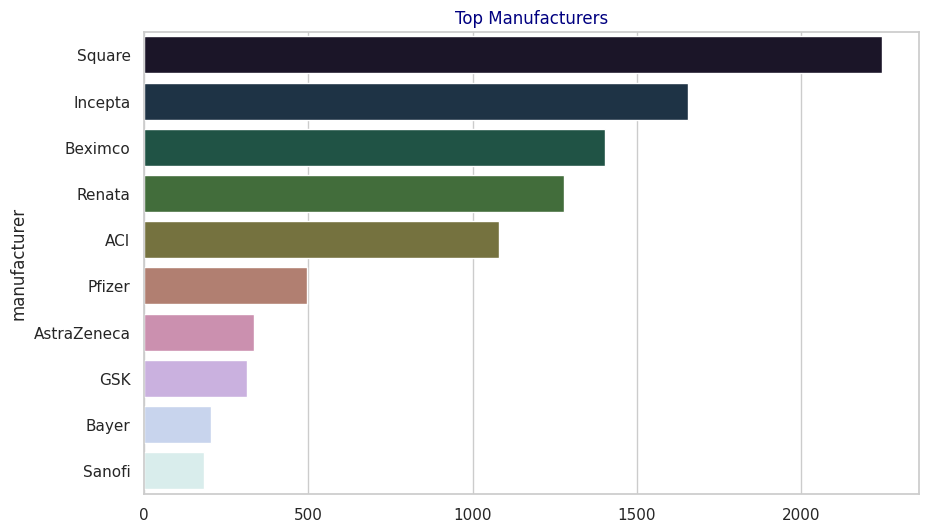

In [24]:
top_manu = df['manufacturer'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_manu.values, y=top_manu.index, palette='cubehelix')
plt.title("Top Manufacturers", color='navy')
plt.show()

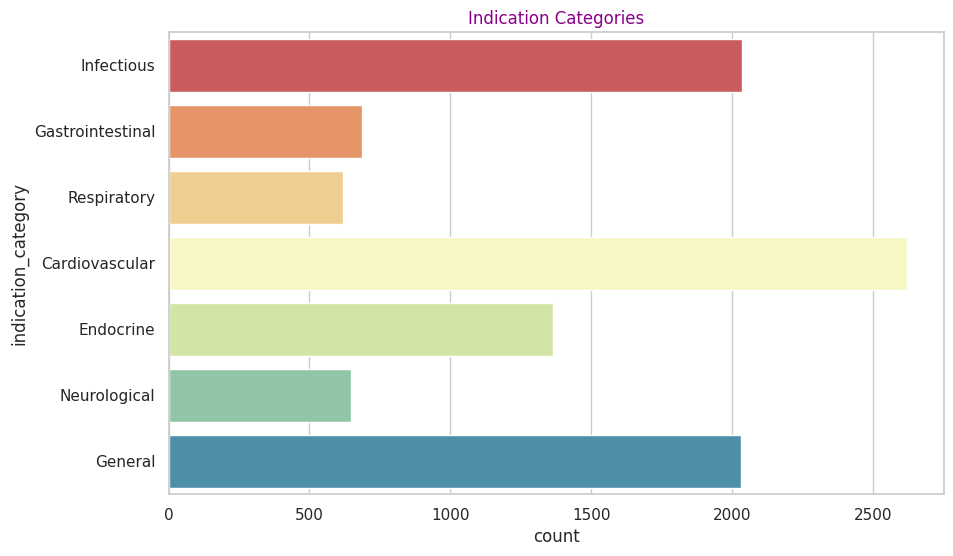

In [25]:
plt.figure()
sns.countplot(data=df, y='indication_category', palette='Spectral')
plt.title("Indication Categories", color='darkmagenta')
plt.show()

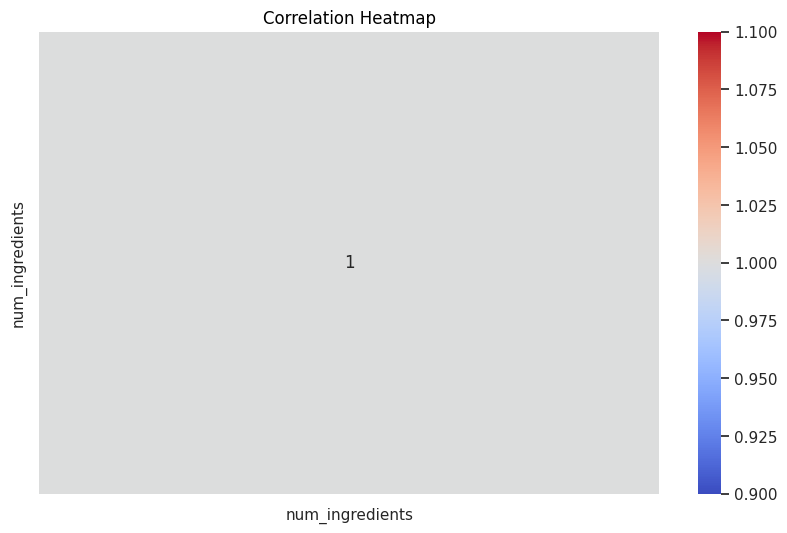

In [26]:
plt.figure()
sns.heatmap(df[['num_ingredients']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap", color='black')
plt.show()

## Feature engineering

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

In [28]:
df = df.drop(columns=['id'])

In [29]:
target_col = 'otc_or_rx'

In [30]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
le_dict = {}

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        le = LabelEncoder()
        
        # Fit ONLY on train
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        
        # Handle unseen labels safely in test
        X_test[col] = X_test[col].map(lambda s: '<UNK>' if s not in le.classes_ else s)
        le.classes_ = np.append(le.classes_, '<UNK>')
        X_test[col] = le.transform(X_test[col].astype(str))
        
        le_dict[col] = le

In [33]:
target_le = LabelEncoder()
y_train = target_le.fit_transform(y_train)
y_test = target_le.transform(y_test)

In [34]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [35]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [36]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.9975
Random Forest Accuracy: 1.0


In [37]:
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))


Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       544
           1       1.00      1.00      1.00      1456

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       544
           1       1.00      1.00      1.00      1456

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [38]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

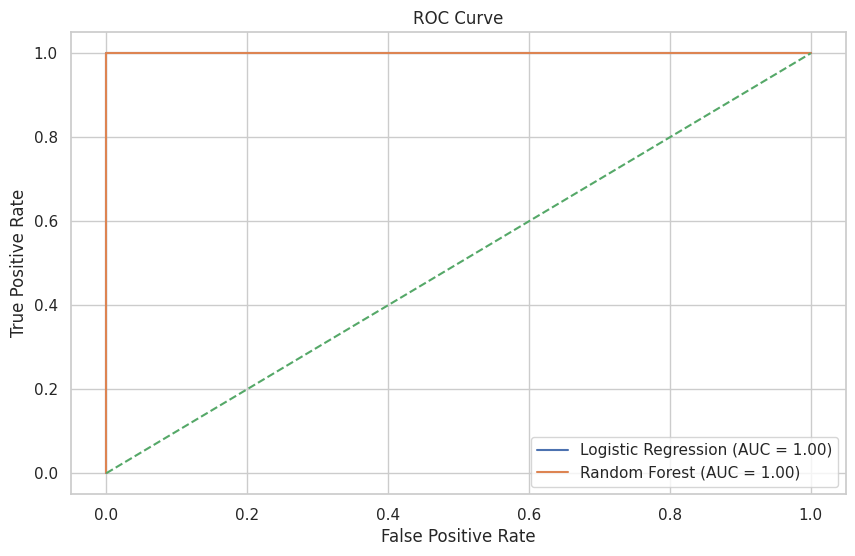

In [39]:
plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

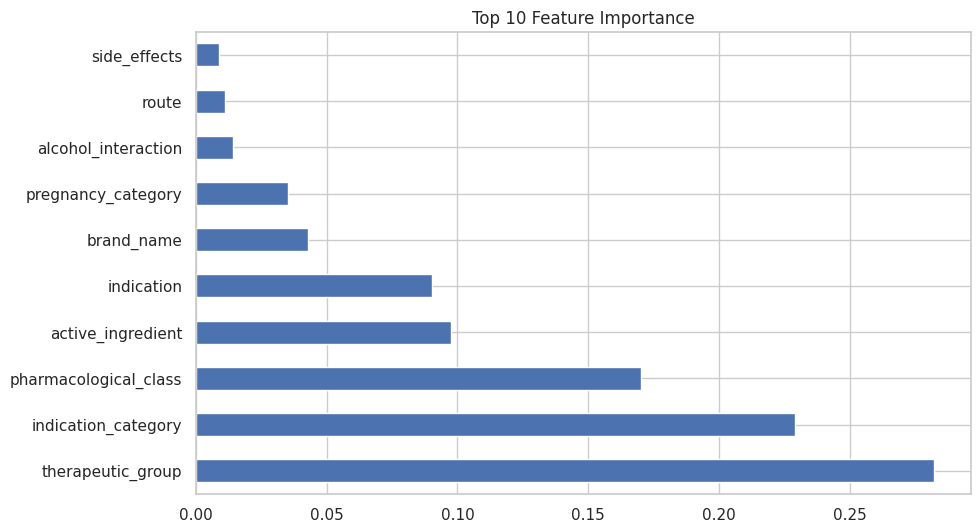

In [40]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure()
importances.plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.show()

## Thank you...pls upvote!!!!!!!